# Tugas #3
## Multiprocessing Python

## 1. Analisis Speedup Skala

### Tujuan
Mengulang eksperimen `hitung_prima` dengan jumlah worker:

**1, 2, 4, dan 8 proses**

Sesuai arahan soal, pool dibuat dengan:

```python
mp.get_context("fork").Pool(processes=...)
```

Kemudian dihitung **speedup**:

\[
Speedup(p) = \frac{T_1}{T_p}
\]

dengan `T1` sebagai waktu eksekusi menggunakan 1 proses dan `Tp` sebagai waktu menggunakan `p` proses.

Untuk membuat eksperimen konsisten dan cukup terukur, program menghitung banyak bilangan prima dari 2 sampai 800.000 dan membagi rentang tersebut menjadi beberapa bagian sesuai jumlah worker.

In [1]:
import math
import multiprocessing as mp
import os
import time
import matplotlib.pyplot as plt

BATAS_ATAS = 800_000

def is_prime(n):
    if n < 2:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False

    batas = math.isqrt(n)
    for pembagi in range(3, batas + 1, 2):
        if n % pembagi == 0:
            return False

    return True

def hitung_prima(rentang):
    awal, akhir = rentang
    return sum(is_prime(n) for n in range(awal, akhir))

def buat_rentang(batas, jumlah_worker):
    edges = [
        2 + (batas - 1) * i // jumlah_worker
        for i in range(jumlah_worker + 1)
    ]
    return [
        (edges[i], edges[i + 1])
        for i in range(jumlah_worker)
    ]

def jalankan_hitung_prima(jumlah_worker):
    tugas = buat_rentang(BATAS_ATAS, jumlah_worker)
    ctx = mp.get_context("fork")

    mulai = time.perf_counter()
    with ctx.Pool(processes=jumlah_worker) as pool:
        jumlah_prima = sum(pool.map(hitung_prima, tugas))
    durasi = time.perf_counter() - mulai

    return jumlah_prima, durasi

try:
    import psutil
    core_fisik = psutil.cpu_count(logical=False)
    core_logis = psutil.cpu_count(logical=True)
except ImportError:
    core_fisik = "tidak terdeteksi"
    core_logis = os.cpu_count()

print("CPU fisik yang terdeteksi :", core_fisik)
print("CPU logis yang terdeteksi :", core_logis)
print("Batas pencarian prima     :", BATAS_ATAS)

CPU fisik yang terdeteksi : 3
CPU logis yang terdeteksi : 3
Batas pencarian prima     : 800000


In [2]:
workers = [1, 2, 4, 8]
waktu = []
jumlah_prima = []

for w in workers:
    hasil, durasi = jalankan_hitung_prima(w)
    jumlah_prima.append(hasil)
    waktu.append(durasi)
    print(
        f"worker={w:2d} | "
        f"jumlah prima={hasil} | "
        f"waktu={durasi:.4f} detik"
    )

speedup = [waktu[0] / t for t in waktu]

print("\nTabel hasil:")
for w, t, s in zip(workers, waktu, speedup):
    print(f"worker={w:2d} | waktu={t:.4f} s | speedup={s:.3f}x")

worker= 1 | jumlah prima=63951 | waktu=1.0439 detik


worker= 2 | jumlah prima=63951 | waktu=0.6593 detik


worker= 4 | jumlah prima=63951 | waktu=0.6441 detik


worker= 8 | jumlah prima=63951 | waktu=0.6800 detik

Tabel hasil:
worker= 1 | waktu=1.0439 s | speedup=1.000x
worker= 2 | waktu=0.6593 s | speedup=1.583x
worker= 4 | waktu=0.6441 s | speedup=1.621x
worker= 8 | waktu=0.6800 s | speedup=1.535x


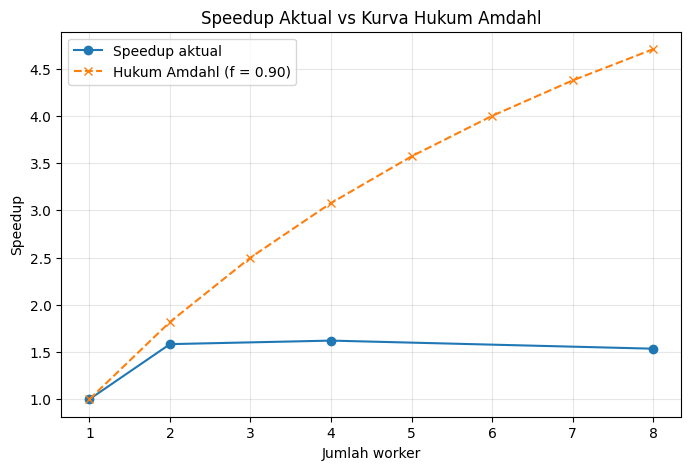

In [3]:
# Kurva Amdahl teoritis.
# Asumsi ilustratif: 90% workload dapat diparalelkan (f = 0.90).
# Nilai ini digunakan sebagai pembanding teoritis, bukan hasil pengukuran mesin.
f = 0.90
worker_teori = list(range(1, 9))
speedup_amdahl = [
    1 / ((1 - f) + (f / p))
    for p in worker_teori
]

plt.figure(figsize=(8, 5))
plt.plot(workers, speedup, marker="o", label="Speedup aktual")
plt.plot(
    worker_teori,
    speedup_amdahl,
    marker="x",
    linestyle="--",
    label="Hukum Amdahl (f = 0.90)"
)
plt.xlabel("Jumlah worker")
plt.ylabel("Speedup")
plt.title("Speedup Aktual vs Kurva Hukum Amdahl")
plt.xticks(worker_teori)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Perbandingan dengan Hukum Amdahl

Hukum Amdahl menyatakan bahwa speedup teoritis dibatasi oleh bagian program yang **tidak dapat diparalelkan**:

\[
S(p)=\frac{1}{(1-f)+\frac{f}{p}}
\]

dengan `f` adalah bagian program yang dapat diparalelkan dan `p` adalah jumlah proses.

Pada grafik digunakan **f = 0,90 sebagai asumsi ilustratif**, sehingga kurva tersebut adalah batas teoritis untuk workload yang 90% dapat diparalelkan, bukan hasil pengukuran mesin.

Kurva aktual dapat berada di bawah kurva teori karena kondisi nyata tidak ideal. Faktor yang perlu dipertimbangkan adalah:

- jumlah **core fisik** mesin dan jumlah core logis;
- overhead membuat, mengatur, dan menghentikan proses;
- komunikasi serta penggabungan hasil antar-proses;
- pembagian workload;
- proses lain yang sedang menggunakan CPU;
- cache dan memory bandwidth.

Pada lingkungan eksekusi notebook ini, jumlah core fisik/logis dicetak pada output. Karena jumlah worker 4 dan 8 dapat melampaui jumlah core yang tersedia, tambahan proses tidak otomatis menghasilkan speedup yang lebih besar. Inilah salah satu alasan kurva aktual cenderung mendatar setelah titik tertentu.

### Kesimpulan Soal 1

Speedup meningkat ketika beberapa bagian perhitungan CPU-bound dijalankan secara paralel, tetapi peningkatannya tidak linear. Pada praktiknya, setelah sejumlah worker tertentu, overhead multiprocessing dan keterbatasan resource mesin membuat tambahan worker memberikan manfaat yang semakin kecil.

## 2. Shared Memory vs Message Passing

### Tujuan
Membandingkan dua cara mengumpulkan total dari **4 proses**, dengan setiap proses membuat dan menjumlahkan **1 juta angka acak**:

1. **Queue (message passing):** setiap proses menghitung subtotal lalu mengirimkannya melalui `multiprocessing.Queue`.
2. **Value + Lock (shared memory):** setiap proses menghitung subtotal lalu menambahkan subtotal tersebut ke `multiprocessing.Value` dengan perlindungan `Lock`.

Seed dibuat tetap agar kedua versi mengolah data acak yang sama sehingga perbandingan waktunya lebih adil.

In [4]:
import multiprocessing as mp
import random
import time

JUMLAH_PROSES = 4
JUMLAH_ANGKA = 1_000_000
SEED = 2026

def jumlah_angka_acak(seed_dan_jumlah):
    seed, jumlah = seed_dan_jumlah
    rng = random.Random(seed)
    return sum(rng.randrange(1, 101) for _ in range(jumlah))

def worker_queue(queue, seed, jumlah):
    subtotal = jumlah_angka_acak((seed, jumlah))
    queue.put(subtotal)

def worker_shared(shared_value, lock, seed, jumlah):
    subtotal = jumlah_angka_acak((seed, jumlah))

    # Lock hanya saat memperbarui shared value.
    with lock:
        shared_value.value += subtotal

In [5]:
def eksperimen_queue():
    ctx = mp.get_context("fork")
    queue = ctx.Queue()

    proses = [
        ctx.Process(
            target=worker_queue,
            args=(queue, SEED + i, JUMLAH_ANGKA)
        )
        for i in range(JUMLAH_PROSES)
    ]

    mulai = time.perf_counter()

    for p in proses:
        p.start()

    for p in proses:
        p.join()

    total = sum(queue.get() for _ in range(JUMLAH_PROSES))
    durasi = time.perf_counter() - mulai

    queue.close()
    queue.join_thread()

    return total, durasi

def eksperimen_shared():
    ctx = mp.get_context("fork")
    shared_value = ctx.Value("q", 0)
    lock = ctx.Lock()

    proses = [
        ctx.Process(
            target=worker_shared,
            args=(shared_value, lock, SEED + i, JUMLAH_ANGKA)
        )
        for i in range(JUMLAH_PROSES)
    ]

    mulai = time.perf_counter()

    for p in proses:
        p.start()

    for p in proses:
        p.join()

    durasi = time.perf_counter() - mulai
    return shared_value.value, durasi

total_queue, waktu_queue = eksperimen_queue()
total_shared, waktu_shared = eksperimen_shared()

print("=== Queue / Message Passing ===")
print(f"Total : {total_queue}")
print(f"Waktu : {waktu_queue:.4f} detik")

print("\n=== Value + Lock / Shared Memory ===")
print(f"Total : {total_shared}")
print(f"Waktu : {waktu_shared:.4f} detik")

print("\nTotal sama?", total_queue == total_shared)
print(f"Perbandingan waktu (Queue / Shared): {waktu_queue / waktu_shared:.3f}x")

=== Queue / Message Passing ===
Total : 201940455
Waktu : 0.7585 detik

=== Value + Lock / Shared Memory ===
Total : 201940455
Waktu : 0.6890 detik

Total sama? True
Perbandingan waktu (Queue / Shared): 1.101x


### Analisis Soal 2

Kedua pendekatan menghasilkan total yang sama karena masing-masing proses menggunakan seed yang sama pada kedua eksperimen.

**Queue / message passing** membuat proses tidak menulis ke variabel bersama. Setiap proses cukup mengirim subtotal, lalu proses utama menggabungkannya. Pendekatan ini jelas secara konsep dan mengurangi risiko konflik pada shared state, tetapi ada overhead komunikasi dan serialisasi objek yang dikirim melalui queue.

**`Value` + `Lock` / shared memory** membuat beberapa proses mengakses lokasi memori bersama. Karena penulisan dilakukan bersama, diperlukan `Lock` agar pembaruan tidak saling menimpa. Dalam implementasi ini lock hanya digunakan sekali per proses untuk menambahkan subtotal, bukan untuk setiap angka. Jika lock digunakan pada setiap penambahan, contention akan jauh lebih besar dan waktu eksekusi dapat meningkat drastis.

Perbedaan waktu aktual bergantung pada CPU, beban sistem, dan overhead proses.

## 3. Producer–Consumer Antar-Proses

### Tujuan
Mengubah pola producer–consumer berbasis thread menjadi:

- `multiprocessing.Queue`
- `multiprocessing.Process`
- **1 producer**
- **3 consumer**

Karena workload dibuat **CPU-bound**, setiap consumer menghitung jumlah bilangan prima pada potongan rentang tertentu. Producer menghasilkan tugas berupa rentang angka, kemudian tiga consumer mengerjakan tugas tersebut secara paralel.

Seperti pada versi thread, setelah producer selesai, producer mengirim **3 sentinel `None`**, satu untuk masing-masing consumer.

In [6]:
import multiprocessing as mp
import math
import time

BATAS_PC = 300_000
JUMLAH_TUGAS = 30
JUMLAH_CONSUMER = 3

def hitung_prima_chunk(rentang):
    awal, akhir = rentang
    total = 0

    for n in range(awal, akhir):
        if n < 2:
            continue
        if n == 2:
            total += 1
            continue
        if n % 2 == 0:
            continue

        prima = True
        for d in range(3, math.isqrt(n) + 1, 2):
            if n % d == 0:
                prima = False
                break

        if prima:
            total += 1

    return total

def producer_mp(queue, batas, jumlah_tugas):
    ukuran = (batas - 2) // jumlah_tugas

    for i in range(jumlah_tugas):
        awal = 2 + i * ukuran
        akhir = (
            batas
            if i == jumlah_tugas - 1
            else 2 + (i + 1) * ukuran
        )
        queue.put((awal, akhir))

    # Satu sentinel untuk setiap consumer.
    for _ in range(JUMLAH_CONSUMER):
        queue.put(None)

def consumer_mp(queue, hasil_queue, nomor):
    subtotal = 0
    jumlah_tugas = 0

    while True:
        tugas = queue.get()

        if tugas is None:
            hasil_queue.put((nomor, subtotal, jumlah_tugas))
            break

        subtotal += hitung_prima_chunk(tugas)
        jumlah_tugas += 1

In [7]:
def jalankan_producer_consumer_mp():
    ctx = mp.get_context("fork")
    task_queue = ctx.Queue()
    result_queue = ctx.Queue()

    producer = ctx.Process(
        target=producer_mp,
        args=(task_queue, BATAS_PC, JUMLAH_TUGAS)
    )

    consumers = [
        ctx.Process(
            target=consumer_mp,
            args=(task_queue, result_queue, i)
        )
        for i in range(1, JUMLAH_CONSUMER + 1)
    ]

    mulai = time.perf_counter()

    for c in consumers:
        c.start()
    producer.start()

    producer.join()

    for c in consumers:
        c.join()

    hasil = [
        result_queue.get()
        for _ in range(JUMLAH_CONSUMER)
    ]

    durasi = time.perf_counter() - mulai

    task_queue.close()
    result_queue.close()
    task_queue.join_thread()
    result_queue.join_thread()

    return hasil, durasi

hasil_pc, waktu_pc = jalankan_producer_consumer_mp()

print("Hasil tiap consumer:")
for nomor, subtotal, jumlah_tugas in sorted(hasil_pc):
    print(
        f"Consumer-{nomor}: "
        f"{jumlah_tugas} tugas, subtotal={subtotal}"
    )

print("\nTotal prima:", sum(x[1] for x in hasil_pc))
print("Waktu eksekusi:", f"{waktu_pc:.4f}", "detik")
print("Jumlah tugas selesai:", sum(x[2] for x in hasil_pc), "/", JUMLAH_TUGAS)

Hasil tiap consumer:
Consumer-1: 10 tugas, subtotal=8843
Consumer-2: 11 tugas, subtotal=9543
Consumer-3: 9 tugas, subtotal=7611

Total prima: 25997
Waktu eksekusi: 0.1705 detik
Jumlah tugas selesai: 30 / 30


### Analisis Soal 3

Secara struktur, pola kode **tidak berubah terlalu banyak**. Konsep utamanya tetap sama:

**producer → queue → consumer**

Perubahan penting adalah API yang digunakan:

- thread: `queue.Queue` + `threading.Thread`
- proses: `multiprocessing.Queue` + `multiprocessing.Process`

Pada workload **CPU-bound**, multiprocessing lebih cocok daripada threading karena beberapa proses dapat menjalankan komputasi Python pada core CPU yang berbeda. Namun, producer–consumer juga mempunyai overhead komunikasi melalui queue. Untuk tugas CPU-bound, pembagian kerja harus cukup besar agar keuntungan paralelisme lebih besar daripada overhead membuat proses dan memindahkan tugas.

Pada eksperimen ini, tiga consumer memproses potongan perhitungan prima secara paralel. Waktu aktual sangat bergantung pada jumlah core, beban sistem, dan ukuran tugas.

## 4. Refleksi Singkat

`Manager()` cocok ketika beberapa proses perlu berbagi objek Python seperti list atau dictionary dengan cara yang relatif mudah diprogram. Contohnya, beberapa worker dapat memperbarui dictionary hasil tanpa programmer harus mengatur mekanisme shared memory secara manual. Trade-off-nya adalah akses melalui `Manager()` melibatkan proses server dan komunikasi antar-proses sehingga umumnya lebih lambat.

Sebaliknya, `Value` atau `Array` lebih sesuai ketika data yang dibagi sederhana dan terstruktur, misalnya satu angka penghitung atau array numerik berukuran tetap. Aksesnya lebih dekat ke shared memory sehingga overhead dapat lebih rendah, tetapi programmer perlu mengatur sinkronisasi seperti `Lock` dan harus memahami keterbatasan tipe data yang dapat dibagi.

Jadi, pilihan bergantung pada kebutuhan: `Manager()` mengutamakan kemudahan berbagi objek Python, sedangkan `Value`/`Array` lebih cocok ketika performa shared memory dan struktur data sederhana lebih penting.